# Лабораторная работа 2: Часть 2. Логистическая регрессия

## 1: Задача бинарной классификации

По результатам двух экзаменов (в 100-балльной шкале) абитурента решит поступит он (1) или не поступит (0).

Начнем с загрузки данных.



In [21]:
# Импорт необходимых библиотек
import numpy as np
import matplotlib.pyplot as plt

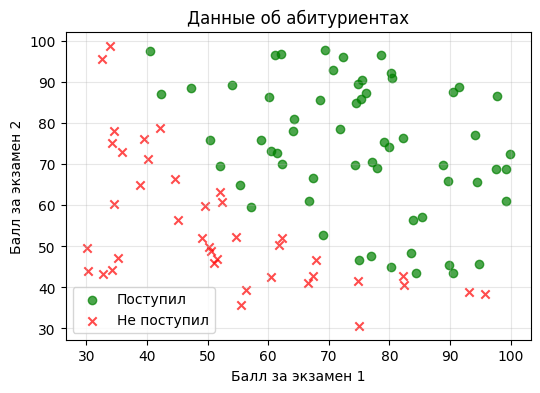

In [22]:
# Загрузка данных из файла
data = np.loadtxt('exam.txt', delimiter=',')
X = data[:, :2]  # первые два столбца - баллы за экзамены
y = data[:, 2]   # третий столбец - поступление (0 или 1)

# Визуализируем данные
plt.figure(figsize=(6, 4))
admitted = y == 1
not_admitted = y == 0

plt.scatter(X[admitted, 0], X[admitted, 1], c='green', marker='o', label='Поступил', alpha=0.7)
plt.scatter(X[not_admitted, 0], X[not_admitted, 1], c='red', marker='x', label='Не поступил', alpha=0.7)

plt.xlabel('Балл за экзамен 1')
plt.ylabel('Балл за экзамен 2')
plt.title('Данные об абитуриентах')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Реализация логистической регрессии

В отличие от линейной регрессии, где мы предсказываем непрерывное значение, в логистической регрессии мы предсказываем **вероятность** принадлежности к классу 1. Для этого мы используем **сигмоидную функцию** (логистическую функцию), которая преобразует линейную комбинацию признаков в значение от 0 до 1:
$$
h_\theta(\mathbf{x}) = \sigma(\theta^T \mathbf{x}) = \frac{1}{1 + e^{-\theta^T \mathbf{x}}},
$$
где:
- $\mathbf{x}$ - вектор признаков (с фиктивным признаком $x_0 = 1$)
- $\theta$ - параметры модели
- $\sigma(z)$ - сигмоидная функция

Вместо MSE теперь мы используем **бинарную перекрёстную энтропию** (log loss):
$$
J(\theta) = -\frac{1}{m} \sum_{i=1}^m \left[ y_i \log(h_\theta(\mathbf{x}_i)) + (1-y_i) \log(1-h_\theta(\mathbf{x}_i)) \right].
$$

Отметим, что формула обновления параметров остается такой же, как в линейной регрессии!
$$
\theta^{(t+1)} = \theta^{(t)} - \eta \cdot \nabla_\theta J(\theta^{(t)}),
$$
где градиент вычисляется как:
$$
\nabla_\theta J(\theta) = \frac{1}{m} \sum_{i=1}^m (h_\theta(\mathbf{x}_i) - y_i) \mathbf{x}_i.
$$
Отличие от линейной регрессии - в функции $h_\theta(\mathbf{x})$.

В следующей ячейке - нормализация данных. Можно попробовать, как с ней, так и без нее. С нормализацией методу градиентного спучка будет легче сойтись.

In [23]:
## Нормализация с StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [24]:
# Добавляем фиктивный признак x₀ = 1 (как в линейной регрессии)
X_with_bias = np.column_stack([np.ones(len(X)), X])

In [25]:
def compute_predictions(X, theta):
    """Вычисление предсказаний: Xθ"""
    return X @ theta

def sigmoid(z):
    """Сигмоидная функция - преобразует любые значения в интервал (0,1)"""
    return 1 / (1 + np.exp(-z))

def compute_loss(X, y, theta):
    """
    Функция потерь (бинарная перекрёстная энтропия) для логистической регрессии
    В линейной регрессии здесь была MSE: L(θ) = 1/(2n) * Σ(y_i - x_iθ)²
    Теперь: J(θ) = -1/m * Σ[y_i log(h_θ(x_i)) + (1-y_i) log(1-h_θ(x_i))]
    """
    m = len(y)
    # добавляем сигмоиду к предсказаниям
    h = sigmoid(compute_predictions(X, theta))

    # Перекрёстная энтропия вместо MSE
    loss = - (1/m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return loss

def compute_gradient(X, y, theta):
    """
    Градиент функции потерь
    В линейной регрессии: ∇L(θ) = (1/n) * Xᵀ(Xθ - y)
    В логистической регрессии формула ТА ЖЕ, но предсказания проходят через сигмоиду!
    """
    m = len(y)
    # добавляем сигмоиду к предсказаниям
    h = sigmoid(compute_predictions(X, theta))
    errors = h - y
    gradient = (1/m) * X.T @ errors
    return gradient

In [26]:
# Проверим работу функций на нулевых начальных параметрах
initial_theta = np.zeros(X_with_bias.shape[1])
initial_loss = compute_loss(X_with_bias, y, initial_theta)
initial_gradient = compute_gradient(X_with_bias, y, initial_theta)

print(f"Начальные параметры: θ = {initial_theta}")
print(f"Значение функция потерь до обучения: L(θ) = {initial_loss:.2f}")
print(f"Начальный градиент: ∇L(θ) = {initial_gradient}")

Начальные параметры: θ = [0. 0. 0.]
Значение функция потерь до обучения: L(θ) = 0.69
Начальный градиент: ∇L(θ) = [-0.1        -0.28122914 -0.25098615]


Функция, реализующая градиентный спуск - та же, что и в линейной регрессии.

In [27]:
def gradient_descent(X, y, initial_theta, learning_rate=0.001, n_iterations=100):
    """Реализация градиентного спуска"""
    theta = initial_theta.copy()
    loss_history = []

    for i in range(n_iterations):
        # Вычисляем градиент
        gradient = compute_gradient(X, y, theta)

        # Обновляем параметры
        theta = theta - learning_rate * gradient

        # Сохраняем значение функции потерь
        loss = compute_loss(X, y, theta)
        loss_history.append(loss)

    return theta, loss_history

In [28]:
# Обучаем модель (так же как в линейной регрессии!)
print("\nЗапуск градиентного спуска:")
theta_optimal, loss_history = gradient_descent(
    X_with_bias, y,
    initial_theta,
    learning_rate=0.001,
    n_iterations=100000
)

print(f"\nРезультаты обучения:")
print(f"Оптимальные параметры: θ₀ = {theta_optimal[0]:.4f}, θ₁ = {theta_optimal[1]:.4f}, θ₂ = {theta_optimal[2]:.4f}")
print(f"Функция потерь после обучения: {loss_history[-1]:.4f}")


Запуск градиентного спуска:

Результаты обучения:
Оптимальные параметры: θ₀ = 1.2707, θ₁ = 3.0472, θ₂ = 2.8115
Функция потерь после обучения: 0.2105


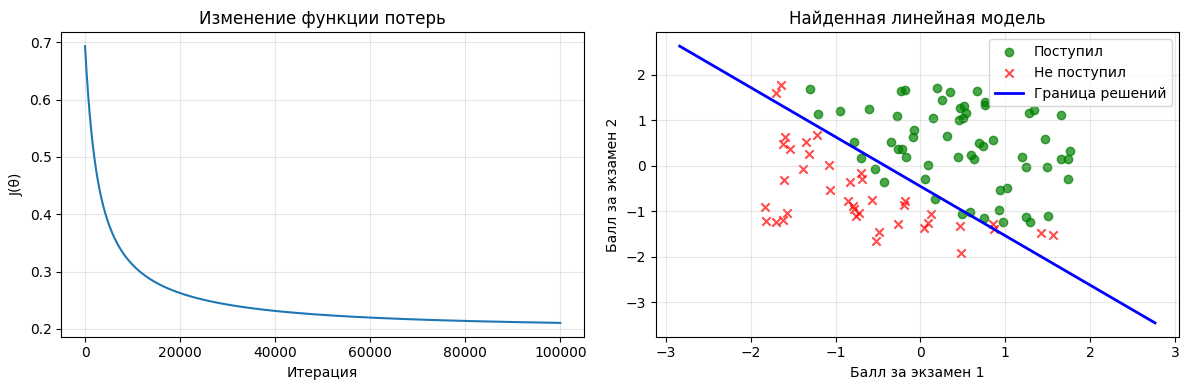

In [29]:
# Визуализация процесса обучения и результата
plt.figure(figsize=(12, 4))

# 1. Изменение функции потерь во время обучения
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel('Итерация')
plt.ylabel('J(θ)')
plt.title('Изменение функции потерь')
plt.grid(True, alpha=0.3)

# 2. Обученная модель на данных
plt.subplot(1, 2, 2)

plt.scatter(X[admitted, 0], X[admitted, 1], c='green', marker='o', label='Поступил', alpha=0.7)
plt.scatter(X[not_admitted, 0], X[not_admitted, 1], c='red', marker='x', label='Не поступил', alpha=0.7)

# Граница решений
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_plot = np.linspace(x1_min, x1_max, 100)
x2_plot = (-theta_optimal[0] - theta_optimal[1] * x1_plot) / theta_optimal[2]

plt.plot(x1_plot, x2_plot, 'blue', linewidth=2, label='Граница решений')

plt.xlabel('Балл за экзамен 1')
plt.ylabel('Балл за экзамен 2')
plt.title('Найденная линейная модель')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Использование метода Ньютона для ускорения сходимости

Как мы видим, классическому градиентному спуску потребовалось 100,000 итераций для достижения хорошего результата. Причем, уменьшение функции потерь не вышло на плато, есть потенциал дальнейшего обучения. Из-за медленной сходимости классический градиентный спуск редко используется на практике.

Давайте воспользуемся **методом Ньютона** (сопряженных градиентов), который учитывает кривизну функции потерь и сходится значительно быстрее.

In [30]:
# Оптимизация методом Ньютона
import scipy.optimize as opt

# Сохраняем историю потерь
newton_loss_history = []

def cost_func(theta, X, y):
    return compute_loss(X, y, theta)

def grad_func(theta, X, y):
    return compute_gradient(X, y, theta)

def callback_func(theta):
    loss = cost_func(theta, X_with_bias, y)
    newton_loss_history.append(loss)

# Запускаем оптимизацию - использовали метод Ньютона
result = opt.fmin_tnc(func=cost_func, x0=initial_theta, fprime=grad_func,
                     args=(X_with_bias, y), callback=callback_func)
theta_newton = result[0]

print(f"Метод Ньютона: {len(newton_loss_history)} итераций")
print(f"Финальные параметры: θ₀ = {theta_newton[0]:.4f}, θ₁ = {theta_newton[1]:.4f}, θ₂ = {theta_newton[2]:.4f}")
print(f"Финальная функция потерь: {newton_loss_history[-1]:.4f}")

Метод Ньютона: 8 итераций
Финальные параметры: θ₀ = 1.7179, θ₁ = 3.9915, θ₂ = 3.7236
Финальная функция потерь: 0.2035


В нашем случае метод сошелся всего за **17 итераций**!


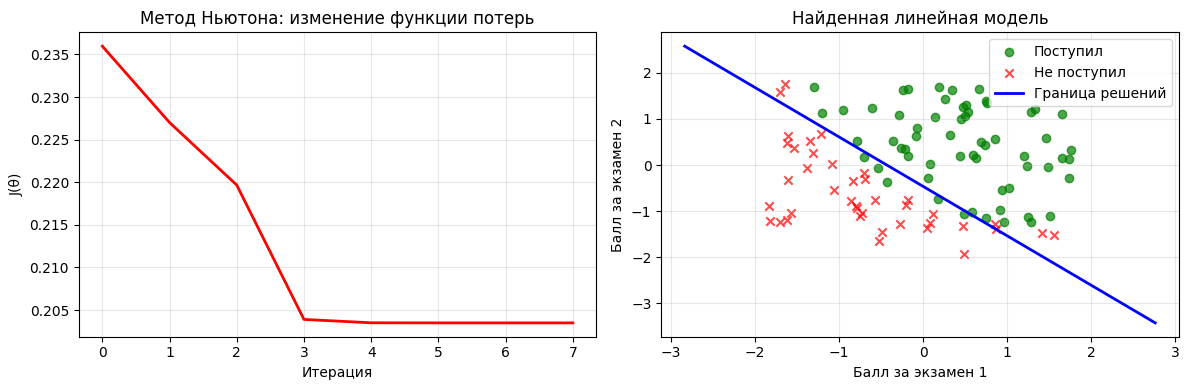

In [31]:
# Визуализация метода Ньютона
plt.figure(figsize=(12, 4))

# 1. Изменение функции потерь
plt.subplot(1, 2, 1)
plt.plot(newton_loss_history, 'red', linewidth=2)
plt.xlabel('Итерация')
plt.ylabel('J(θ)')
plt.title('Метод Ньютона: изменение функции потерь')
plt.grid(True, alpha=0.3)

# 2. Граница решений
plt.subplot(1, 2, 2)

plt.scatter(X[admitted, 0], X[admitted, 1], c='green', marker='o', label='Поступил', alpha=0.7)
plt.scatter(X[not_admitted, 0], X[not_admitted, 1], c='red', marker='x', label='Не поступил', alpha=0.7)

# Строим границу решений
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_plot = np.linspace(x1_min, x1_max, 100)
x2_plot = (-theta_newton[0] - theta_newton[1] * x1_plot) / theta_newton[2]

plt.plot(x1_plot, x2_plot, 'blue', linewidth=2, label='Граница решений')
plt.xlabel('Балл за экзамен 1')
plt.ylabel('Балл за экзамен 2')
plt.title('Найденная линейная модель')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Интересно наблюдать за изменением функции потерь: "ступенька" демонстрирует адаптивность метода Ньютона - он автоматически подстраивает размер шага в зависимости от локальной геометрии функции. На каждой итерации метод вычисляет оптимальную длину шага на основе матрицы Гессе (вторых производных) и учитывает кривизну поверхности, делая большие шаги в областях с малой кривизной и малые шаги  в областях с большой кривизной.

Подобный характер сходимости характерен для методов второго порядка, которые могут делать большие шаги в правильном направлении, в отличие от градиентного спуска с постоянным маленьким шагом.
Они часто быстро находят область минимума, а потом "дотюнивают" параметры.

In [32]:
# Предсказание для абитуриента с баллами [85, 40]
test_student = np.array([85, 40])
test_student = scaler.transform([test_student])  # нормализуем, если бучали модель на нормализованных данных
test_student_with_bias = np.insert(test_student, 0, 1)  # добавляем x₀=1

# Вычисляем вероятность
probability = sigmoid(test_student_with_bias @ theta_newton)
print(f"Вероятность поступления: {probability:.2%}")

Вероятность поступления: 60.53%



### Использование готовой реализации LogisticRegression

На практике вам редко придется реализовывать логистическую регрессию с нуля. Библиотека `scikit-learn` предоставляет готовую  реализацию, которая решает ту же задачу всего в несколько строк кода:


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Создаем и обучаем модель
model = LogisticRegression()
model.fit(X, y)

# Предсказания
y_pred = model.predict(X)

# Оценка точности accuracy
accuracy = accuracy_score(y, y_pred)
print(f"Точность LogisticRegression: {accuracy:.3f}")

# Параметры модели
print(f"Параметры модели: θ₀ = {model.intercept_[0]:.4f}, θ₁ = {model.coef_[0][0]:.4f}, θ₂ = {model.coef_[0][1]:.4f}")

Точность LogisticRegression: 0.890
Параметры модели: θ₀ = 1.0025, θ₁ = 2.2849, θ₂ = 2.0916


In [34]:
# Предсказание для тестового абитуриента с баллами [85, 40]
test_student = [[85, 40]]
probability = model.predict_proba(test_student)[0][1]
prediction = model.predict(test_student)[0]

print(f"Для абитуриента с баллами [85, 40]:")
print(f"Вероятность поступления: {probability:.2%}")
print(f"Предсказание: {'Поступит' if prediction == 1 else 'Не поступит'}")

Для абитуриента с баллами [85, 40]:
Вероятность поступления: 100.00%
Предсказание: Поступит


# Задание: Борьба с переобучением через регуляризацию

**Описание данных:**
В файле `instrument_test_data.txt` содержатся результаты тестирования приборов. Каждая строка представляет один прибор:
- **Первый столбец**: Ошибка измерения в тесте 1
- **Второй столбец**: Ошибка измерения в тесте 2  
- **Третий столбец**: Состояние прибора (0 - исправен, 1 - неисправен)

**Условие прохождения теста:** Прибор считается исправным, если обе ошибки измерения близки к нулю.

**Цель:** Построить модель, которая по ошибкам измерений будет предсказывать состояние прибора.

### 1: Создание сложной модели

1. **Добавьте полиномиальные признаки до 10-й степени**
   - Используйте `PolynomialFeatures(degree=10)`
   - Посмотрите, сколько признаков получилось
   - Объясните, почему теперь модель может строить сложные границы

2. **Обучите логистическую регрессию без регуляризации**
   - Используйте `LogisticRegression(C=100,  max_iter=1000)` (слабая регуляризация)
   - Постройте границу решений - код ниже
   - Что значит число 0.5 в строке в этом коде?
   
     `plt.contour(xx1, xx2, Z, levels=[0.5], colors='blue', linewidths=2)`
   - Обсудите: не слишком ли сложная граница? Есть ли переобучение?

### 2: Управление сложностью модели

3. **Экспериментируйте с параметром C**
   - `C=0.001` - очень сильная регуляризация
   - `C=1` - средняя регуляризация (значение по умолчанию)  
   - `C=100` - слабая регуляризация

   Для каждого значения:
   - Обучите модель
   - Постройте границу решений
   - Сравните точность и сложность границы

4. **Сделайте вывод, как регуляризация влияет на форму границы?**


## Ниже фрагменты кода, которые будут Вам полезны.

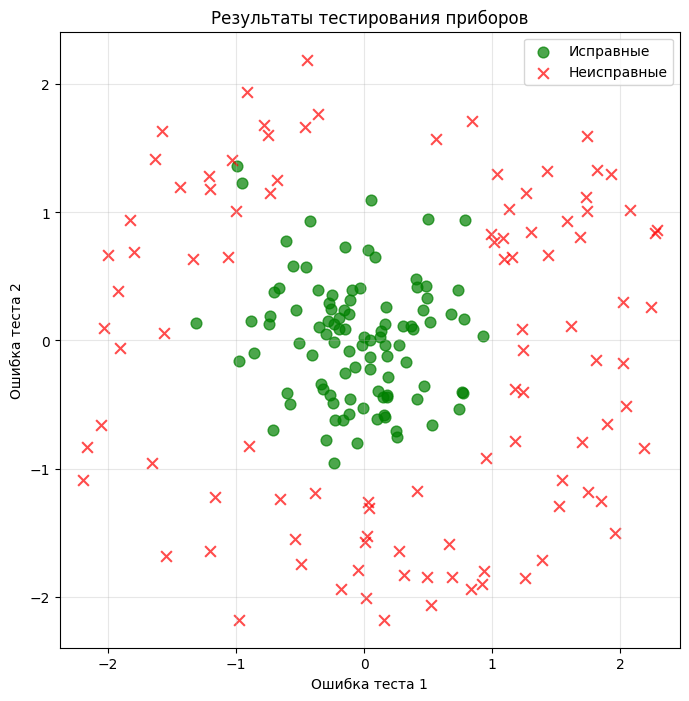

In [35]:
# Загрузка данных тестирования приборов
data = np.loadtxt('instrument_test_data.txt', delimiter=',')
X = data[:, :2]  # ошибки тестов
y = data[:, 2]   # состояние прибора (0-исправен, 1-неисправен)

# Визуализация данных
plt.figure(figsize=(8, 8))

good = y == 0
bad = y == 1

plt.scatter(X[good, 0], X[good, 1],
           c='green', marker='o', label='Исправные', alpha=0.7, s=60)
plt.scatter(X[bad, 0], X[bad, 1],
           c='red', marker='x', label='Неисправные', alpha=0.7, s=60)

plt.xlabel('Ошибка теста 1')
plt.ylabel('Ошибка теста 2')
plt.title('Результаты тестирования приборов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

Для добавления признаков будет полезен код.

In [36]:
from sklearn.preprocessing import PolynomialFeatures

# Создаем полиномиальные признаки до 10-й степени
poly = PolynomialFeatures(degree=10, include_bias=False)
X_poly = poly.fit_transform(X)

print(f"Исходная размерность: {X.shape}")
print(f"После добавления полиномиальных признаков: {X_poly.shape}")
print(f"Количество признаков: {X_poly.shape[1]}")

Исходная размерность: (200, 2)
После добавления полиномиальных признаков: (200, 65)
Количество признаков: 65


Теперь у нас есть 65 признаков вместо 2! Модель получила возможность строить сложные нелинейные границы решений, т.к. выход модели имеет вид:

$$
h_\theta(\mathbf{x}) = \sigma(\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 + \theta_4 x_1 x_2 + \theta_5 x_2^2 + \ldots + \theta_{65} x_2^{10})
$$
где:
- $\sigma(z)$ - сигмоидная функция
- $\theta_0, \theta_1, \ldots, \theta_{65}$ - параметры модели  
- $x_1, x_2$ - исходные признаки (ошибки тестов)


Для обучения и визуализации границы будет полезен следующий код.

In [ ]:
# Обучаем Logistic Regression на полиномиальных признаках
model_poly = LogisticRegression(C=100, max_iter=1000)
model_poly.fit(X_poly, y)

# Предсказания и оценка точности
y_pred_poly = model_poly.predict(X_poly)
accuracy_poly = accuracy_score(y, y_pred_poly)

print(f"Точность с полиномиальными признаками: {accuracy_poly:.3f} ({accuracy_poly*100:.1f}%)")

Точность с полиномиальными признаками: 1.000 (100.0%)


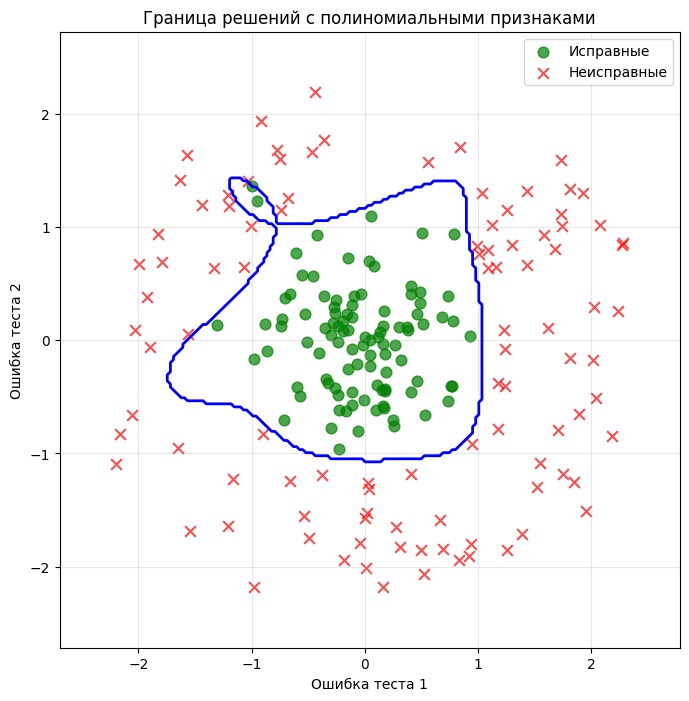

In [38]:
def plot_decision_boundary_poly(model, poly, X, y):
    """Визуализация границы решений для модели с полиномиальными признаками"""

    # Создаем сетку для построения границы
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                           np.linspace(x2_min, x2_max, 200))

    # Преобразуем сетку в полиномиальные признаки
    grid_points = np.c_[xx1.ravel(), xx2.ravel()]
    grid_poly = poly.transform(grid_points)

    # Предсказания для всей сетки
    Z = model.predict(grid_poly)
    Z = Z.reshape(xx1.shape)

    # Визуализация
    plt.figure(figsize=(8, 8))

    good = y == 0
    bad = y == 1

    plt.scatter(X[good, 0], X[good, 1], c='green', marker='o', label='Исправные', alpha=0.7, s=60)
    plt.scatter(X[bad, 0], X[bad, 1], c='red', marker='x', label='Неисправные', alpha=0.7, s=60)

    # Рисуем границу решений
    plt.contour(xx1, xx2, Z, levels=[0.5], colors='blue', linewidths=2)

    plt.xlabel('Ошибка теста 1')
    plt.ylabel('Ошибка теста 2')
    plt.title('Граница решений с полиномиальными признаками')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

# Строим границу решений
plot_decision_boundary_poly(model_poly, poly, X, y)